# OIBSIP Data Analytics — Task 1
## EDA on Retail Sales Data

**Objective:** Perform exploratory data analysis to uncover sales trends, customer behaviour, product performance, and actionable business insights.

This notebook follows the OASIS INFOBYTE Data Analytics Task 1 checklist.

### Dataset
The notebook can use a local `retail_sales_dataset.csv`. If the file is not present, the next cell downloads the public dataset used for this project.

**Expected columns:** Transaction ID, Date, Customer ID, Gender, Age, Product Category, Quantity, Price per Unit, Total Amount.

In [1]:
import os
import urllib.request
from pathlib import Path

DATA_URL = 'https://raw.githubusercontent.com/Oragant/Retail-Sales-Dashboard/main/retail_sales_dataset.csv'
DATA_FILE = Path('retail_sales_dataset.csv')

if not DATA_FILE.exists():
    print('Downloading dataset...')
    urllib.request.urlretrieve(DATA_URL, DATA_FILE)
    print('Dataset downloaded successfully.')
else:
    print('Using existing local dataset:', DATA_FILE)


Dataset downloaded successfully.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

df = pd.read_csv(DATA_FILE)
print('Dataset loaded.')
display(df.head())


Dataset loaded.


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


## 1. Initial Inspection

In [3]:
print('Shape:', df.shape)
print('\nData types:')
display(df.dtypes.to_frame('dtype'))
print('\nMissing values:')
display(df.isnull().sum().to_frame('missing_values'))
print('\nDuplicate rows:', df.duplicated().sum())


Shape: (1000, 9)

Data types:


,dtype
Transaction ID,int64
Date,object
Customer ID,object
Gender,object
Age,int64
Product Category,object
Quantity,int64
Price per Unit,int64
Total Amount,int64



Missing values:


,missing_values
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0



Duplicate rows: 0


**Observation:** The checks above confirm the dataset size, column types, missing values, and duplicate records before analysis.

## 2. Data Preparation

In [4]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
numeric_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.drop_duplicates().copy()
df['Month'] = df['Date'].dt.to_period('M').astype(str)
df['Quarter'] = df['Date'].dt.to_period('Q').astype(str)
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[0, 17, 25, 35, 45, 55, 65, 120],
    labels=['Under 18', '18-25', '26-35', '36-45', '46-55', '56-65', '66+'],
    include_lowest=True
)
print('Data preparation completed.')


Data preparation completed.


## 3. Descriptive Statistics

In [5]:
desc = pd.DataFrame({
    'Mean': df[numeric_cols].mean(),
    'Median': df[numeric_cols].median(),
    'Mode': df[numeric_cols].mode().iloc[0],
    'Standard Deviation': df[numeric_cols].std()
})
display(desc)


,Mean,Median,Mode,Standard Deviation
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


**Observation:** The table gives the central tendency and variability of age, quantity, unit price, and transaction amount.

## 4. Monthly Sales Trend

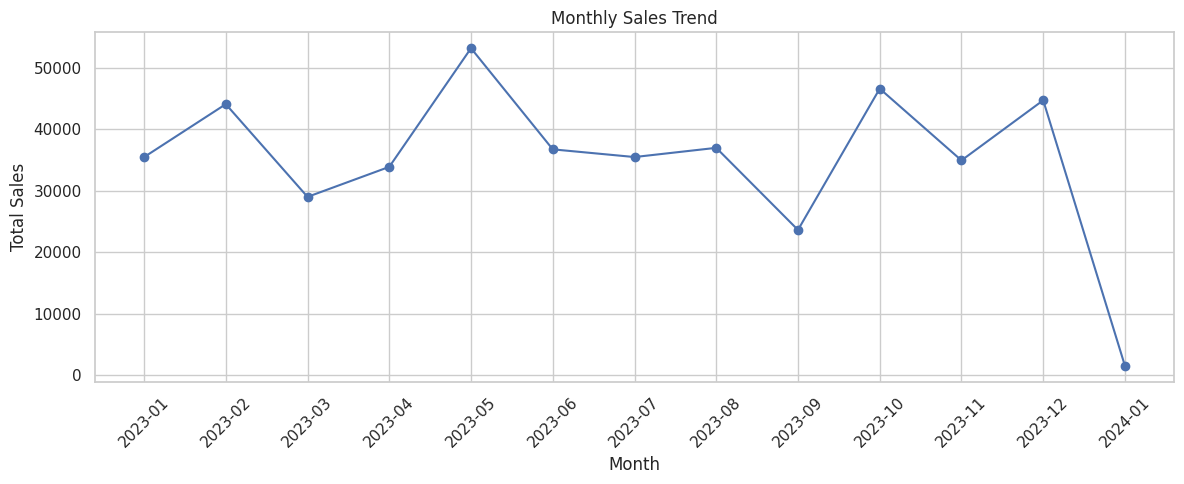

Observation: The highest-sales month is 2023-05 with sales of 53,150.00.


In [6]:
monthly_sales = df.groupby('Month', as_index=False)['Total Amount'].sum()
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales['Month'], monthly_sales['Total Amount'], marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

best_month = monthly_sales.loc[monthly_sales['Total Amount'].idxmax()]
print(f"Observation: The highest-sales month is {best_month['Month']} with sales of {best_month['Total Amount']:,.2f}.")


## 5. Quarterly Sales Trend

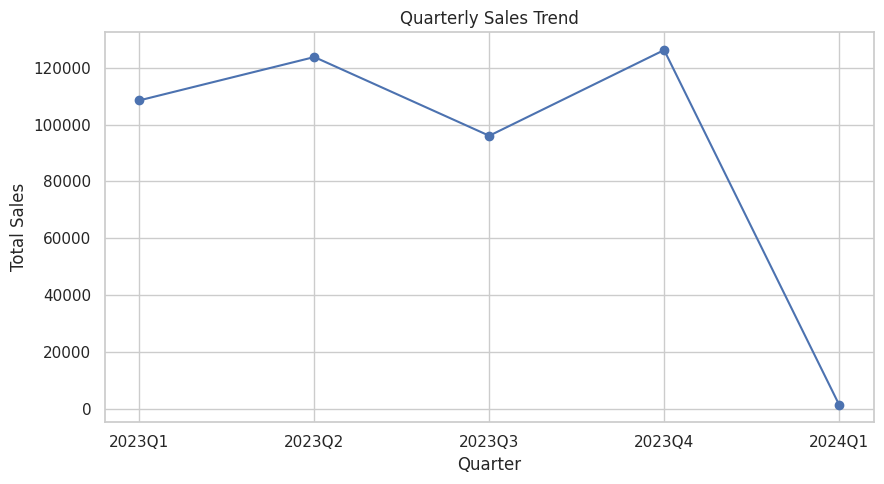

Observation: The strongest quarter is 2023Q4 with sales of 126,190.00.


In [7]:
quarterly_sales = df.groupby('Quarter', as_index=False)['Total Amount'].sum()
plt.figure(figsize=(9, 5))
plt.plot(quarterly_sales['Quarter'], quarterly_sales['Total Amount'], marker='o')
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

best_quarter = quarterly_sales.loc[quarterly_sales['Total Amount'].idxmax()]
print(f"Observation: The strongest quarter is {best_quarter['Quarter']} with sales of {best_quarter['Total Amount']:,.2f}.")


## 6. Customer Demographics — Age Groups

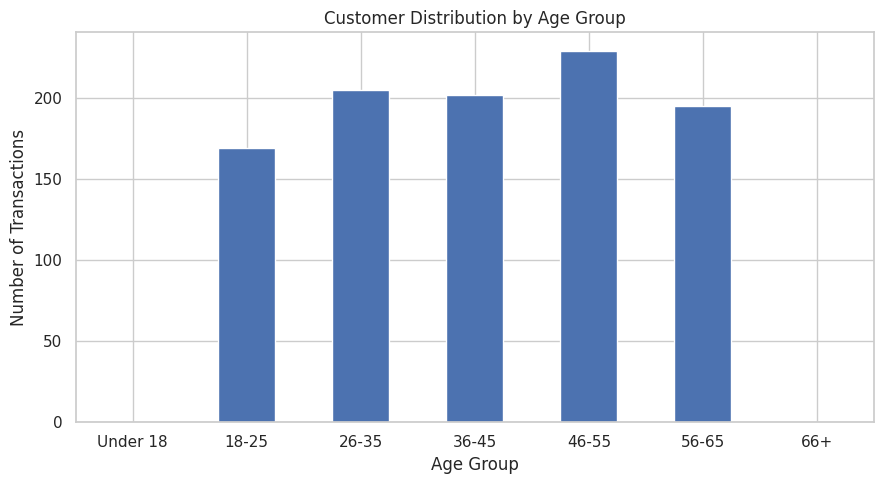

Observation: The 46-55 age group has the highest number of transactions.


In [8]:
age_counts = df['Age Group'].value_counts().sort_index()
plt.figure(figsize=(9, 5))
age_counts.plot(kind='bar')
plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

top_age = age_counts.idxmax()
print(f"Observation: The {top_age} age group has the highest number of transactions.")


## 7. Customer Demographics — Gender

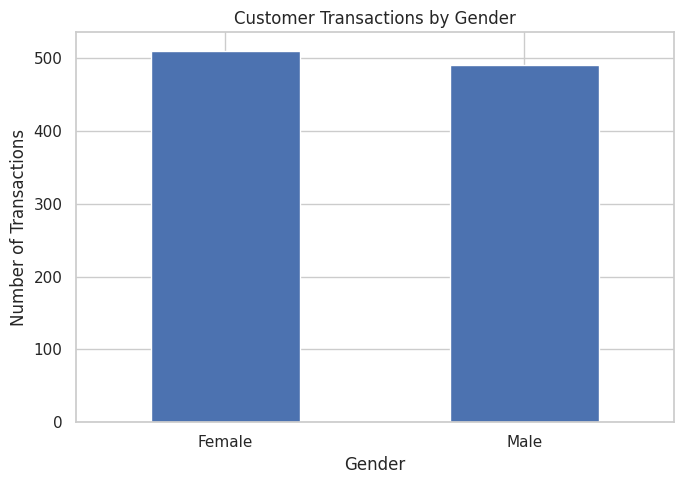

Observation: Gender distribution is shown above and can be used to compare customer engagement.


In [9]:
gender_counts = df['Gender'].value_counts()
plt.figure(figsize=(7, 5))
gender_counts.plot(kind='bar')
plt.title('Customer Transactions by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('Observation: Gender distribution is shown above and can be used to compare customer engagement.')


## 8. Top 10 Best-Selling Products

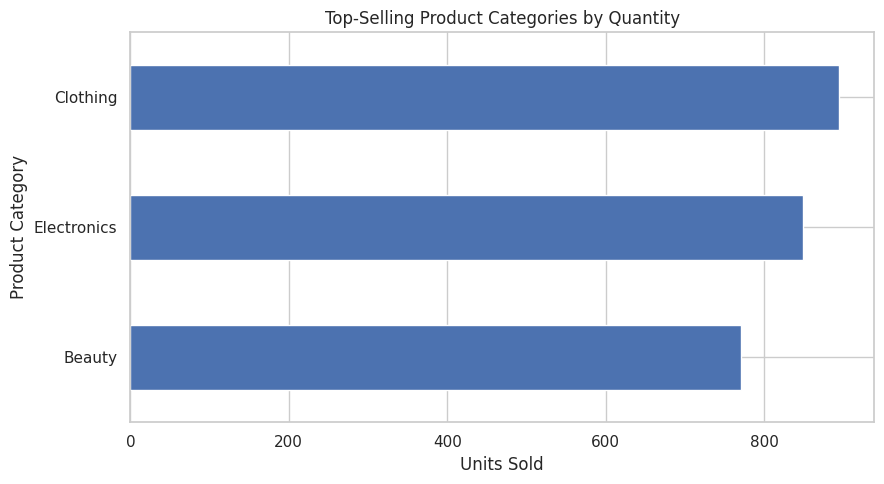

Observation: The available dataset contains Product Category, not individual Product Name, so category-level quantity is used for this checklist item.


In [10]:
# This dataset has product categories rather than individual product names,
# so the Top 10 is based on the highest-selling transactions/categories available.
top_products = (df.groupby('Product Category')['Quantity']
                .sum().sort_values(ascending=False).head(10))
plt.figure(figsize=(9, 5))
top_products.sort_values().plot(kind='barh')
plt.title('Top-Selling Product Categories by Quantity')
plt.xlabel('Units Sold')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()

print('Observation: The available dataset contains Product Category, not individual Product Name, so category-level quantity is used for this checklist item.')


## 9. Revenue by Product Category

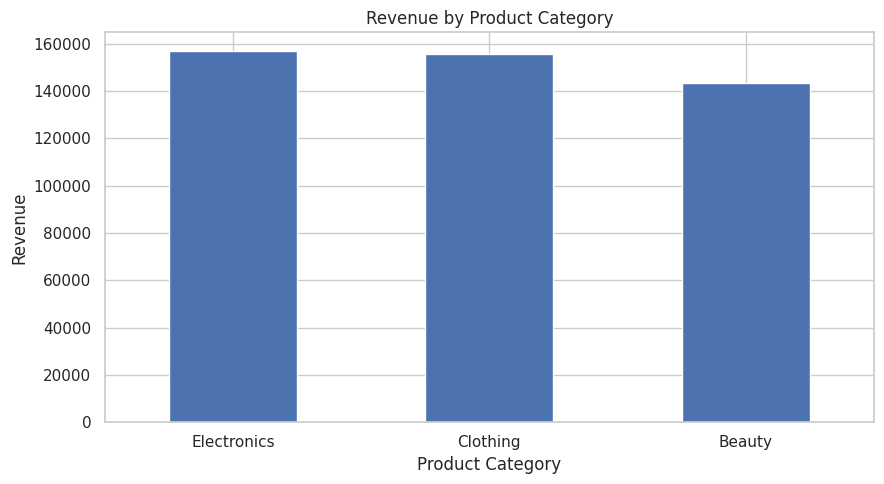

Observation: Electronics generates the highest revenue among the available categories.


In [11]:
category_revenue = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
plt.figure(figsize=(9, 5))
category_revenue.plot(kind='bar')
plt.title('Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

best_category = category_revenue.idxmax()
print(f"Observation: {best_category} generates the highest revenue among the available categories.")


## 10. Correlation Heatmap

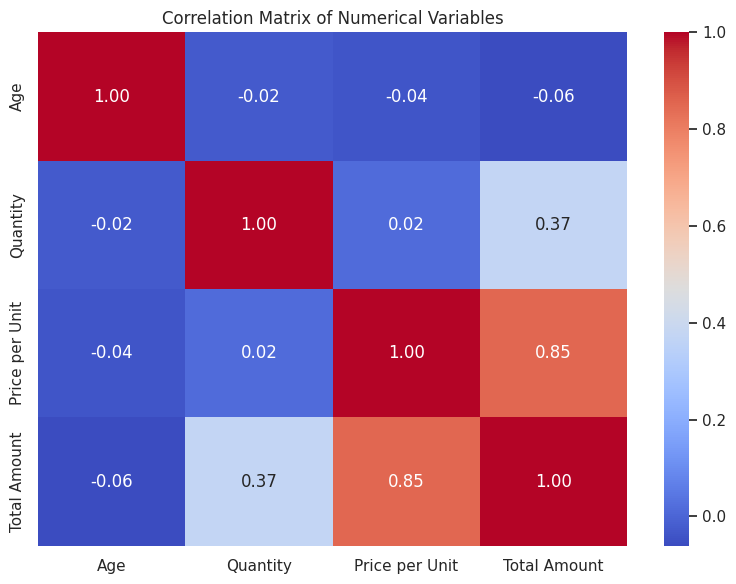

Observation: The heatmap shows the strength and direction of relationships between numerical variables.


In [12]:
corr_cols = ['Age', 'Quantity', 'Price per Unit', 'Total Amount']
plt.figure(figsize=(8, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables')
plt.tight_layout()
plt.show()

print('Observation: The heatmap shows the strength and direction of relationships between numerical variables.')


## 11. Additional Visualization — Sales by Age Group

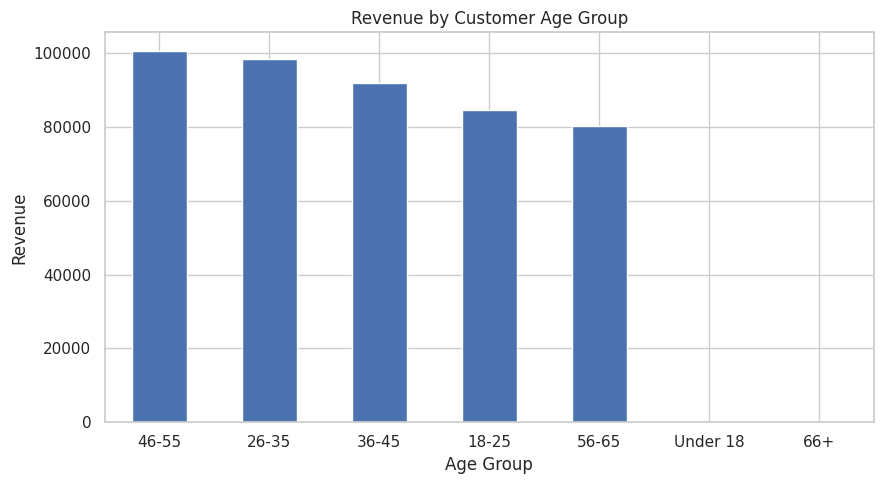

Observation: The 46-55 age group contributes the most revenue in this dataset.


In [13]:
age_sales = df.groupby('Age Group', observed=False)['Total Amount'].sum().sort_values(ascending=False)
plt.figure(figsize=(9, 5))
age_sales.plot(kind='bar')
plt.title('Revenue by Customer Age Group')
plt.xlabel('Age Group')
plt.ylabel('Revenue')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

top_age_sales = age_sales.idxmax()
print(f"Observation: The {top_age_sales} age group contributes the most revenue in this dataset.")


## 12. Key Business Metrics

In [14]:
metrics = {
    'Total Revenue': df['Total Amount'].sum(),
    'Total Transactions': len(df),
    'Unique Customers': df['Customer ID'].nunique(),
    'Average Transaction Value': df['Total Amount'].mean(),
    'Total Units Sold': df['Quantity'].sum()
}
display(pd.Series(metrics, name='Value').to_frame())


,Value
Total Revenue,456000.0
Total Transactions,1000.0
Unique Customers,1000.0
Average Transaction Value,456.0
Total Units Sold,2514.0


## 13. Conclusion and Actionable Recommendations

1. **Prioritise the strongest revenue category:** Focus inventory planning, promotions, and merchandising on the category generating the highest revenue.
2. **Use seasonal planning:** Increase inventory and promotional activity ahead of the strongest months/quarters identified by the time-series analysis.
3. **Target high-value age segments:** Tailor offers and campaigns toward the age group contributing the most revenue.
4. **Use customer demographics carefully:** Compare gender and age-group performance when designing targeted campaigns rather than using one broad customer strategy.
5. **Monitor transaction economics:** Track quantity, unit price, and total amount together to understand what drives transaction value.

## Task 1 Checklist
- [x] Dataset loading and initial inspection
- [x] Descriptive statistics: mean, median, mode, standard deviation
- [x] Monthly sales trend
- [x] Quarterly sales trend
- [x] Customer age-group analysis
- [x] Gender breakdown
- [x] Product/category sales analysis
- [x] Revenue by category
- [x] Correlation heatmap
- [x] Additional visualization
- [x] Markdown observations
- [x] Actionable recommendations


### Dataset Source
Public retail sales CSV used by this project: Oragant/Retail-Sales-Dashboard on GitHub.

### Internship Source
OASIS INFOBYTE Data Analytics — Task 1: EDA on Retail Sales Data.